In [1]:
# importing major libraries 

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('loan_approval_dataset.csv').drop(columns='loan_id')

In [4]:
df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [5]:
df.shape

(4269, 12)

In [6]:
# df.loan_status
df.columns.str.strip()

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')

In [9]:
df.loan_status.unique()

array([' Approved', ' Rejected'], dtype=object)

In [10]:
df.loan_status = df.loan_status.map({' Approved':1, ' Rejected':0})

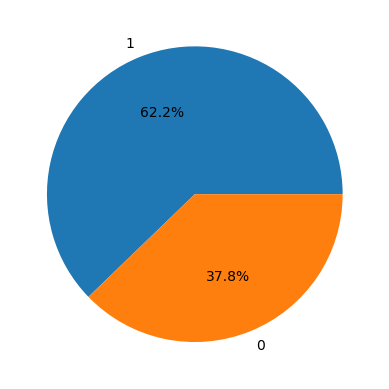

loan_status
1    2656
0    1613
Name: count, dtype: int64

In [11]:
plt.pie(df.loan_status.value_counts(),labels=df.loan_status.value_counts().index,autopct='%1.1f%%')
plt.show()
df.loan_status.value_counts()

In [12]:
df.education.unique()

df.education = df.education.str.strip()
df.self_employed = df.self_employed.str.strip()

In [13]:
# column transformer 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
l1 = ['Graduate', 'Not Graduate']
l2 = ['No', 'Yes']
trans1 = ColumnTransformer([
    ('tr1',OneHotEncoder(categories=[l1],drop='first',dtype='int'),['education']),
    ('tr2',OneHotEncoder(categories=[l2],drop='first',dtype='int'),['self_employed']),
],remainder='passthrough')
trans1

ColumnTransformer(remainder='passthrough',
                  transformers=[('tr1',
                                 OneHotEncoder(categories=[['Graduate',
                                                            'Not Graduate']],
                                               drop='first', dtype='int'),
                                 ['education']),
                                ('tr2',
                                 OneHotEncoder(categories=[['No', 'Yes']],
                                               drop='first', dtype='int'),
                                 ['self_employed'])])

In [14]:
# df.education.unique()
# df.self_employed.unique()

In [15]:
x = df.iloc[:,0:-1]
y = df.loan_status

# train test split 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.ensemble import RandomForestClassifier
rdc = RandomForestClassifier(max_depth=3,n_jobs=-1,n_estimators=101)
rdc

RandomForestClassifier(max_depth=3, n_estimators=101, n_jobs=-1)

In [16]:
# fit 

x_train = pd.DataFrame(trans1.fit_transform(x_train),columns=trans1.get_feature_names_out()) # fit_transform
x_test = pd.DataFrame(trans1.transform(x_test),columns=trans1.get_feature_names_out()) # transform

In [17]:
rdc.fit(x_train,y_train)

RandomForestClassifier(max_depth=3, n_estimators=101, n_jobs=-1)

In [18]:
y_pred = rdc.predict(x_test)

from sklearn.metrics import accuracy_score,precision_score,f1_score

print('accuracy',accuracy_score(y_test,y_pred))
print('precision',precision_score(y_test,y_pred))
print('f1_score',f1_score(y_test,y_pred))

accuracy 0.9625292740046838
precision 0.9941176470588236
f1_score 0.9694072657743786


In [19]:
# fitting 

rdc.score(x_train,y_train)

0.9642752562225476

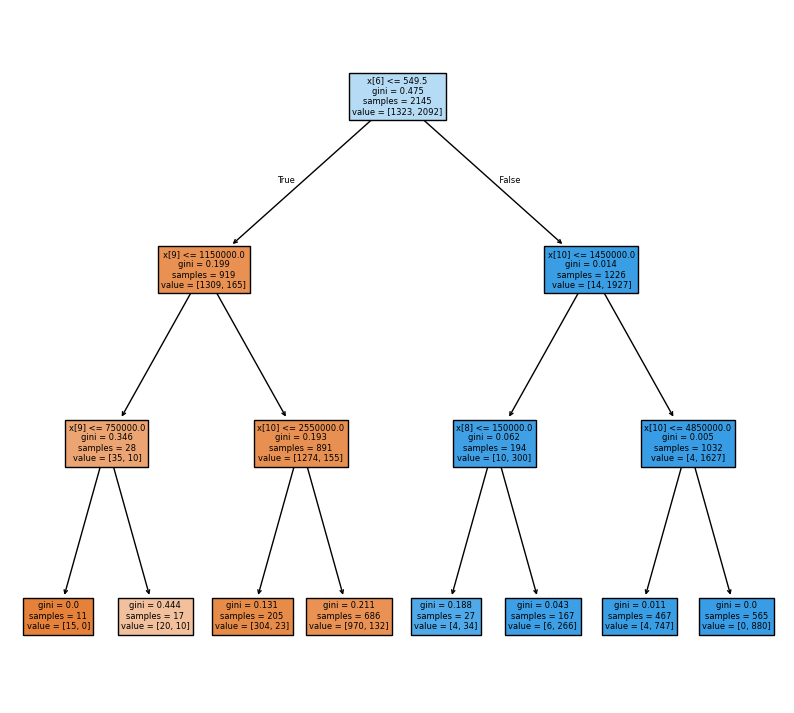

------------------------------------------------------------------------------------------------------------------------


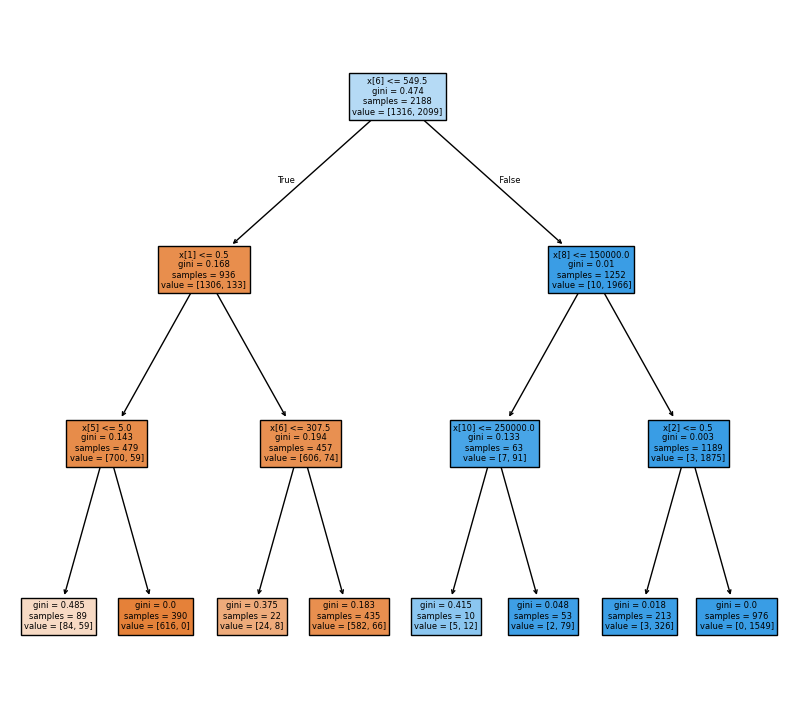

------------------------------------------------------------------------------------------------------------------------


In [20]:
from sklearn import tree
for i in range(2):
    plt.figure(figsize=(10,9)) 
    tree.plot_tree(rdc[i],filled=True)
    plt.show()
    print('-'*120)

In [21]:
rdc.feature_importances_

array([7.10728223e-05, 7.55272355e-05, 2.96279874e-03, 8.58064968e-03,
       1.99787542e-02, 1.42040157e-01, 7.70043182e-01, 1.83811748e-02,
       1.18411506e-02, 1.39951639e-02, 1.20303690e-02])

In [22]:
temp = pd.Series(rdc.feature_importances_,index=x_train.columns).reset_index()

In [23]:
temp.columns = ['feature','importance']
temp

,feature,importance
0,tr1__education_Not Graduate,0.000071
1,tr2__self_employed_Yes,0.000076
2,remainder__no_of_dependents,0.002963
3,remainder__income_annum,0.008581
4,remainder__loan_amount,0.019979
5,remainder__loan_term,0.142040
6,remainder__cibil_score,0.770043
7,remainder__residential_assets_value,0.018381
8,remainder__commercial_assets_value,0.011841
9,remainder__luxury_assets_value,0.013995


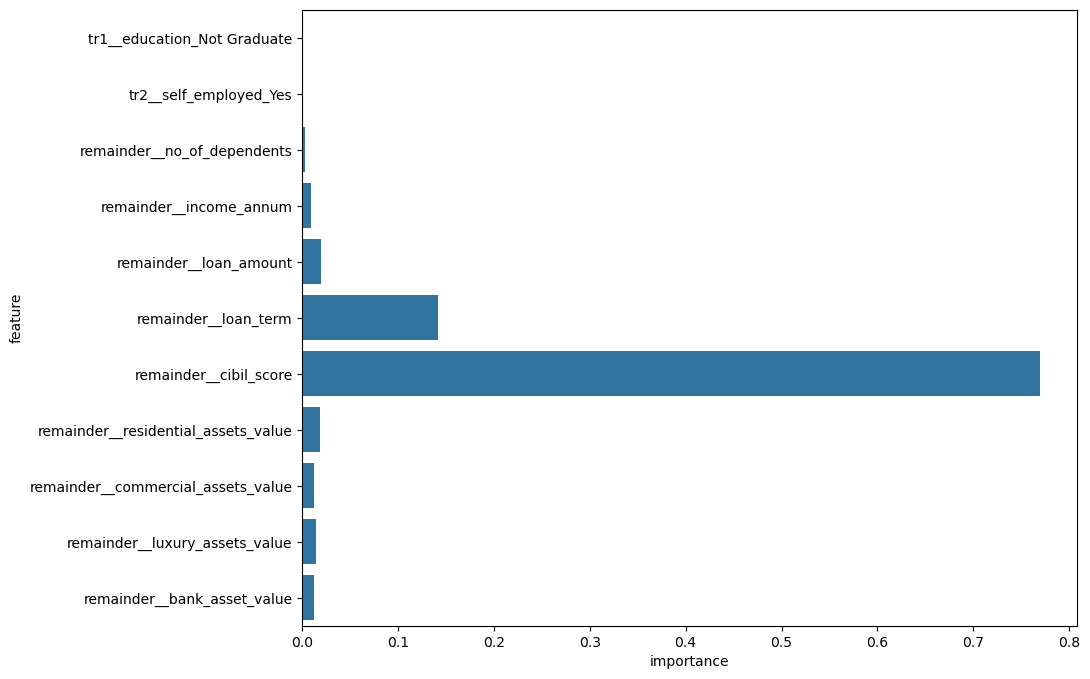

In [24]:
plt.figure(figsize=(10,8))
sns.barplot(data=temp,x='importance',y='feature')
plt.show()

In [25]:
# classification 

m1 = RandomForestClassifier(criterion='entropy',max_depth=4,
                            min_samples_split=11,
                            min_samples_leaf=10,
                            ccp_alpha=0.1)
m2 = RandomForestClassifier(criterion='entropy',
                            max_depth=10,min_samples_split=51,
                            min_samples_leaf=2,max_features='log2')

# criterion , gini, entropy  --> classification
# criterion, squared_error, absolute_error
# max_features --> sqrt 
# None, sqrt, log2, 20
# 100 ---> 10 
# log2 --> log2(100) --> 6.64 --> 6 
# splitter 
# ccp alpha --> pruning 
# 0.01--0.1

In [26]:
m1.fit(x_train,y_train)
m2.fit(x_train,y_train)


RandomForestClassifier(criterion='entropy', max_depth=10, max_features='log2',
                       min_samples_leaf=2, min_samples_split=51)

In [27]:
print('bias',m1.score(x_train,y_train))
print('var',accuracy_score(y_test,m1.predict(x_test)))
print('-'*50)
print('bias',m2.score(x_train,y_train))
print('var',accuracy_score(y_test,m2.predict(x_test)))


bias 0.9537335285505124
var 0.9601873536299765
--------------------------------------------------
bias 0.9862371888726208
var 0.9718969555035128


In [28]:
# grid search cv
from sklearn.model_selection import GridSearchCV #seedha
#smartwork
from sklearn.model_selection import RandomizedSearchCV


In [29]:
param_dist = {
    'criterion':['gini','entropy'],
    'max_depth':[3,4,5,6,7,8,9,None],
    'ccp_alpha':[0,0.1,0.1],
    'min_samples_split':[10,20,30,40,50,60,100,None],
    'min_samples_leaf':[5,10,20,30,40,50,None]
}

In [33]:
m3 = RandomForestClassifier()
grid = GridSearchCV(m3,param_grid=param_dist,cv=5)
grid_ran=RandomizedSearchCV(estimator=m3,param_distributions=param_dist,n_iter=5,cv=5)
grid_ran


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=5,
                   param_distributions={'ccp_alpha': [0, 0.1, 0.1],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9,
                                                      None],
                                        'min_samples_leaf': [5, 10, 20, 30, 40,
                                                             50, None],
                                        'min_samples_split': [10, 20, 30, 40,
                                                              50, 60, 100,
                                                              None]})

In [34]:
#grid.fit(x_train,y_train)
grid_ran.fit(x_train,y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=5,
                   param_distributions={'ccp_alpha': [0, 0.1, 0.1],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9,
                                                      None],
                                        'min_samples_leaf': [5, 10, 20, 30, 40,
                                                             50, None],
                                        'min_samples_split': [10, 20, 30, 40,
                                                              50, 60, 100,
                                                              None]})

In [35]:
grid_ran.best_estimator_
grid_ran.best_score_
grid_ran.best_params_

{'min_samples_split': 60,
 'min_samples_leaf': 50,
 'max_depth': None,
 'criterion': 'entropy',
 'ccp_alpha': 0.1}

In [36]:
# pipelines

from sklearn.pipeline import Pipeline

trans = ColumnTransformer([
    ('tr1',OneHotEncoder(categories=[l1],drop='first',dtype='int'),['education']),
    ('tr2',OneHotEncoder(categories=[l2],drop='first',dtype='int'),['self_employed']),
],remainder='passthrough')
trans

ColumnTransformer(remainder='passthrough',
                  transformers=[('tr1',
                                 OneHotEncoder(categories=[['Graduate',
                                                            'Not Graduate']],
                                               drop='first', dtype='int'),
                                 ['education']),
                                ('tr2',
                                 OneHotEncoder(categories=[['No', 'Yes']],
                                               drop='first', dtype='int'),
                                 ['self_employed'])])

In [37]:
estimator = RandomForestClassifier(min_samples_split=30,
 min_samples_leaf=50,
 max_depth=None,
 criterion='entropy',
 ccp_alpha=0.1)
estimator

RandomForestClassifier(ccp_alpha=0.1, criterion='entropy', min_samples_leaf=50,
                       min_samples_split=30)

In [39]:
Pipeline([
    ('transform',trans),
    ('estimator',estimator)
])

Pipeline(steps=[('transform',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('tr1',
                                                  OneHotEncoder(categories=[['Graduate',
                                                                             'Not '
                                                                             'Graduate']],
                                                                drop='first',
                                                                dtype='int'),
                                                  ['education']),
                                                 ('tr2',
                                                  OneHotEncoder(categories=[['No',
                                                                             'Yes']],
                                                                drop='first',
                                                                dtype='int'),
                                                  ['self_employed'])])),
                ('estimator',
                 RandomForestClassifier(ccp_alpha=0.1, criterion='entropy',
                                        min_samples_leaf=50,
                                        min_samples_split=30))])